In [14]:
# --- 코어 패키지 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1-1. 데이터 로드

In [15]:
df = pd.read_csv('ai4i2020.csv')

In [16]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [17]:
print(f"Shape: {df.shape}")
print("\nColumns:\n,", df.columns.tolist())

Shape: (10000, 14)

Columns:
, ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## 1-2. 컬럼 정리

- `UDI` : 행 고유번호 (1~10,000)
- `Product ID` : 품질등급 문자(L/M/H) + 일련번호
- `Type` : 제품 품질 등급 — L(저, 50%) / M(중, 30%) / H(고, 20%). 유일한 범주형 변수
- `Air temperature[K]` : 작업장 공기 온도. 약 300K(≈27℃) 근처, 표준편차 2K
- `Process temperature[K]` : 공정 온도
- `Rotational speed [rpm]` : 회전 속도. 2860W 출력 기준으로 산출 + 노이즈
- `Torque [Nm]` : 토크. 평균 40Nm, 표준편차 10, 음수 없음
- `Tool wear [min]` : 공구 마모 누적 시간(분). 품질등급 H/M/L에 따라 회당 5/3/2분씩 증가
- `Machine failure`: 타겟 컬럼

**타겟 & 고장 유형**
`Machine failure`는 아래 5개 중 하나라도 1이면 1이 되는 종합 라벨이다.
- `TWF` : Tool Wear Failure (공구 마모)
- `HDF` : Heat Dissipation Failure (방열 실패)
- `PWF` : Power Failure (동력 이상)
- `OSF` : Overstrain Failure (과부하)
- `RNF` : Random Failure (무작위)

## 1-3. 기초 점검

In [18]:
df.info()

print("\n결측치:", df.isnull().sum().sum(), "개")
print("중복 행:", df.duplicated().sum().sum(), "개")

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 1-4. 타겟 분포 - 불균형 확인

In [19]:
counts = df['Machine failure'].value_counts()
print(counts)
print(f"\n고장 비율: {counts[1] / len(df) * 100.:.2f}%")

# 고장 유형별 건수
fails = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("\n고장 유형별 건수: ")
print(df[fails].sum().sort_values(ascending = False))

Machine failure
0    9661
1     339
Name: count, dtype: int64

고장 비율: 3.39%

고장 유형별 건수: 
HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


## 1-5. 정상 vs 고장 분포 비교

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20596\2844885777.py:19: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20596\2844885777.py:19: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20596\2844885777.py:19: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20596\2844885777.py:19: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming

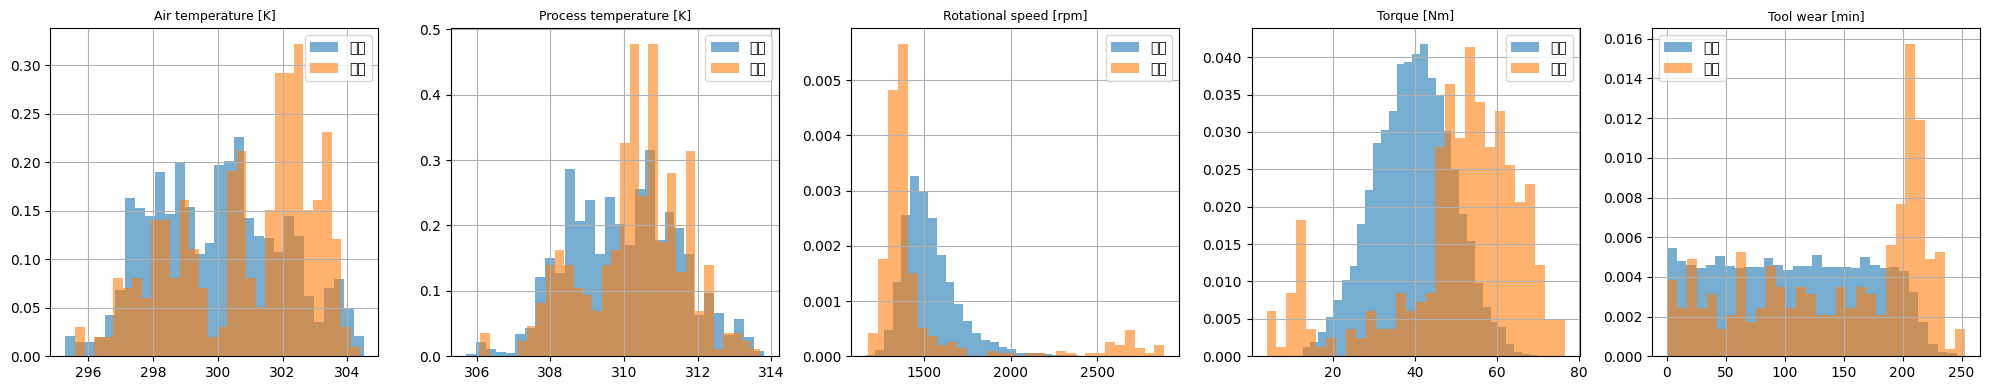

In [21]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, features):
    df[df["Machine failure"] == 0][col].hist(
        ax=ax, bins=30, alpha=0.6, label="정상", density=True
    )
    df[df["Machine failure"] == 1][col].hist(
        ax=ax, bins=30, alpha=0.6, label="고장", density=True
    )
    ax.set_title(col, fontsize=9)
    ax.legend()
plt.tight_layout()
plt.show()